In [1]:
import os
import pandas as pd
import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, average_precision_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

for folder in ["data/splits", "data/processed", "results/checkpoints", "results/plots"]:
    os.makedirs(folder, exist_ok=True)

Device: cuda


# **Load MTAT annotations, top-50 tags, splits**

In [2]:
mtat_root = "/kaggle/input/datasets/yalumusic/magnatagatune"
audio_dir = f"{mtat_root}/MagnaTagATune"

tags_df = pd.read_csv(f"{mtat_root}/annotations_final.csv", sep="\t")
tag_columns = tags_df.columns[1:-1]
tag_counts = tags_df[tag_columns].sum().sort_values(ascending=False)
top_50_tags = tag_counts.head(50).index.tolist()

mtat_df = tags_df[tags_df[top_50_tags].sum(axis=1) > 0].reset_index(drop=True)
mtat_df["folder"] = mtat_df["mp3_path"].str.split("/").str[0]

train_folders = list("0123456789ab")
val_folders = ["c"]
test_folders = ["d", "e", "f"]
train_df = mtat_df[mtat_df["folder"].isin(train_folders)].reset_index(drop=True)
val_df = mtat_df[mtat_df["folder"].isin(val_folders)].reset_index(drop=True)
test_df = mtat_df[mtat_df["folder"].isin(test_folders)].reset_index(drop=True)

failed_paths = [
    "6/norine_braun-now_and_zen-08-gently-117-146.mp3",
    "8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3",
    "9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3",
]
train_df = train_df[~train_df["mp3_path"].isin(failed_paths)].reset_index(drop=True)
val_df = val_df[~val_df["mp3_path"].isin(failed_paths)].reset_index(drop=True)
test_df = test_df[~test_df["mp3_path"].isin(failed_paths)].reset_index(drop=True)

print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))

Train/Val/Test: 15247 1529 4332


# **Audio and graph functions**

In [6]:
def load_audio(path, sr=22050):
    y, sr = librosa.load(path, sr=sr, mono=True)
    return y, sr

def get_melspectrogram(y, sr, n_mels=128):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel, ref=1.0).T
    mean = log_mel.mean(axis=0, keepdims=True)
    std = log_mel.std(axis=0, keepdims=True) + 1e-8
    return (log_mel - mean) / std

def split_into_segments(feature_matrix, sr, hop_length=512, window_seconds=5.0):
    frames_per_segment = int(window_seconds * sr / hop_length)
    segments = []
    for start in range(0, feature_matrix.shape[0], frames_per_segment):
        chunk = feature_matrix[start:start + frames_per_segment]
        if len(chunk) > 0:
            segments.append(chunk.mean(axis=0))
    return segments

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

def build_segment_graph(segments, similarity_threshold=0.5):
    n = len(segments)
    edges = set()
    for i in range(n - 1):
        edges.add((i, i + 1))
    for i in range(n):
        for j in range(i + 1, n):
            if cosine_similarity(segments[i], segments[j]) > similarity_threshold:
                edges.add((i, j))
    return list(edges)

# **Install torch_geometric, define caching function**

In [7]:
!pip install -q torch_geometric

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool

def process_and_cache_clip(mp3_path, save_path):
    y, sr = load_audio(f"{audio_dir}/{mp3_path}")
    mel = get_melspectrogram(y, sr)
    segments = split_into_segments(mel, sr)
    edges = build_segment_graph(segments)
    x = torch.tensor(np.array(segments), dtype=torch.float32)
    edge_index = torch.tensor([[0], [0]], dtype=torch.long) if len(edges) == 0 else torch.tensor(edges, dtype=torch.long).t().contiguous()
    torch.save(Data(x=x, edge_index=edge_index), save_path)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.3 MB/s eta 0:00:00a 0:00:01


# **Cache all MTAT clips**

In [8]:
import time

clips_to_cache = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)
print("Total clips to cache:", len(clips_to_cache))

start = time.time()
processed, skipped, failed = 0, 0, 0
for i, row in clips_to_cache.iterrows():
    save_path = f"data/processed/{row['clip_id']}.pt"
    if os.path.exists(save_path):
        skipped += 1
        continue
    try:
        process_and_cache_clip(row["mp3_path"], save_path)
        processed += 1
    except Exception as e:
        failed += 1
        print(f"Failed on {row['mp3_path']}: {e}")
    if (i + 1) % 2000 == 0:
        print(f"{i+1}/{len(clips_to_cache)} | processed {processed}, failed {failed} | {(time.time()-start)/60:.1f} min")

print(f"Done. Processed {processed}, skipped {skipped}, failed {failed}. Total: {(time.time()-start)/60:.1f} min")

Total clips to cache: 21108
2000/21108 | processed 2000, failed 0 | 2.9 min
4000/21108 | processed 4000, failed 0 | 5.6 min
6000/21108 | processed 6000, failed 0 | 8.3 min
8000/21108 | processed 8000, failed 0 | 11.0 min
10000/21108 | processed 10000, failed 0 | 13.7 min
12000/21108 | processed 12000, failed 0 | 16.5 min
14000/21108 | processed 14000, failed 0 | 19.2 min
16000/21108 | processed 16000, failed 0 | 22.2 min
18000/21108 | processed 18000, failed 0 | 25.0 min
20000/21108 | processed 20000, failed 0 | 27.9 min
Done. Processed 21108, skipped 0, failed 0. Total: 29.4 min


# **explore the annotations folder structure**

In [9]:
deam_root = "/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music"

annotations_root = f"{deam_root}/DEAM_Annotations/annotations"
print("Top level:", os.listdir(annotations_root))

avg_dir = f"{annotations_root}/annotations averaged per song"
print("Averaged-per-song contents:", os.listdir(avg_dir))

Top level: ['annotations per each rater', 'annotations averaged per song']
Averaged-per-song contents: ['dynamic (per second annotations)', 'song_level']


In [10]:
song_level_dir = f"{avg_dir}/song_level"
print(os.listdir(song_level_dir))

['static_annotations_averaged_songs_2000_2058.csv', 'static_annotations_averaged_songs_1_2000.csv']


# **load both files and inspect columns first**

In [11]:
deam_csv_1 = pd.read_csv(f"{song_level_dir}/static_annotations_averaged_songs_1_2000.csv")
deam_csv_2 = pd.read_csv(f"{song_level_dir}/static_annotations_averaged_songs_2000_2058.csv")

print("File 1 columns:", deam_csv_1.columns.tolist())
print("File 1 shape:", deam_csv_1.shape)
print("File 2 columns:", deam_csv_2.columns.tolist())
print("File 2 shape:", deam_csv_2.shape)

File 1 columns: ['song_id', ' valence_mean', ' valence_std', ' arousal_mean', ' arousal_std']
File 1 shape: (1744, 5)
File 2 columns: ['song_id', ' valence_mean', ' valence_std', ' valence_ max_mean', ' valence_max_std', ' valence_min_mean', ' valence_min_std', ' arousal_mean', ' arousal_std', ' arousal_max_mean', ' arousal_max_std', ' arousal_min_mean', ' arousal_min_std']
File 2 shape: (58, 13)


# **clean column names, extract only what we need, combine**

In [12]:
deam_csv_1.columns = deam_csv_1.columns.str.strip()
deam_csv_2.columns = deam_csv_2.columns.str.strip()

deam_1_clean = deam_csv_1[["song_id", "valence_mean", "arousal_mean"]]
deam_2_clean = deam_csv_2[["song_id", "valence_mean", "arousal_mean"]]

deam_df = pd.concat([deam_1_clean, deam_2_clean], ignore_index=True)
print("Combined DEAM annotations shape:", deam_df.shape)
print(deam_df.head())
print("Valence range:", deam_df["valence_mean"].min(), "-", deam_df["valence_mean"].max())
print("Arousal range:", deam_df["arousal_mean"].min(), "-", deam_df["arousal_mean"].max())

Combined DEAM annotations shape: (1802, 3)
   song_id  valence_mean  arousal_mean
0        2           3.1           3.0
1        3           3.5           3.3
2        4           5.7           5.5
3        5           4.4           5.3
4        7           5.8           6.4
Valence range: 1.6 - 8.4
Arousal range: 1.6 - 8.1


# **link each song_id to its actual mp3 file, and build the full audio path**

In [13]:
deam_audio_dir = f"{deam_root}/DEAM_audio/MEMD_audio"
deam_df["mp3_path"] = deam_df["song_id"].apply(lambda sid: f"{deam_audio_dir}/{sid}.mp3")
deam_df["exists"] = deam_df["mp3_path"].apply(os.path.exists)

print("Files found:", deam_df["exists"].sum(), "/", len(deam_df))
deam_df = deam_df[deam_df["exists"]].reset_index(drop=True)

Files found: 1802 / 1802


# **split and cache, following the same pattern as GTZAN**

In [14]:
from sklearn.model_selection import train_test_split

deam_train, deam_temp = train_test_split(deam_df, test_size=0.3, random_state=42)
deam_val, deam_test = train_test_split(deam_temp, test_size=2/3, random_state=42)

print("Train:", len(deam_train), "Val:", len(deam_val), "Test:", len(deam_test))

Train: 1261 Val: 180 Test: 361


# **cache DEAM audio as graphs, same pipeline as MTAT/GTZAN**

In [15]:
os.makedirs("data/processed/deam", exist_ok=True)

def process_and_cache_deam_clip(mp3_path, save_path):
    y, sr = load_audio(mp3_path)
    mel = get_melspectrogram(y, sr)
    segments = split_into_segments(mel, sr)
    edges = build_segment_graph(segments)
    x = torch.tensor(np.array(segments), dtype=torch.float32)
    edge_index = torch.tensor([[0], [0]], dtype=torch.long) if len(edges) == 0 else torch.tensor(edges, dtype=torch.long).t().contiguous()
    torch.save(Data(x=x, edge_index=edge_index), save_path)

processed, failed = 0, 0
for i, row in deam_df.iterrows():
    save_path = f"data/processed/deam/{row['song_id']}.pt"
    if os.path.exists(save_path):
        continue
    try:
        process_and_cache_deam_clip(row["mp3_path"], save_path)
        processed += 1
    except Exception as e:
        failed += 1
        print(f"Failed on {row['mp3_path']}: {e}")

print(f"Done. Processed {processed}, failed {failed}.")

Done. Processed 1802, failed 0.


# **BERT Setup**

In [31]:
!pip install -q transformers
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased")

def freeze_bottom_layers(bert, num_layers_to_freeze=8):
    for param in bert.embeddings.parameters():
        param.requires_grad = False
    for layer in bert.encoder.layer[:num_layers_to_freeze]:
        for param in layer.parameters():
            param.requires_grad = False

freeze_bottom_layers(bert, num_layers_to_freeze=8)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# **GNN encoder (same architecture as Task 2's GNNEncoder)**

In [32]:
class GNNEncoder(nn.Module):
    def __init__(self, in_dim=128, hidden_dim=128, num_layers=3, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        dims = [in_dim] + [hidden_dim] * num_layers
        for i in range(num_layers):
            self.convs.append(SAGEConv(dims[i], dims[i + 1]))
        self.dropout = dropout
        self.out_dim = hidden_dim

    def forward(self, x, edge_index, batch):
        h = x
        for i, conv in enumerate(self.convs):
            h = conv(h, edge_index)
            if i < len(self.convs) - 1:
                h = torch.relu(h)
                h = nn.functional.dropout(h, p=self.dropout, training=self.training)
        return global_mean_pool(h, batch)

# **FUSION MODEL**

In [33]:
class FusionModel(nn.Module):
    """
    Combines one vector from the GNN (summarizing the audio graph) with
    the BERT token sequence (summarizing the tag-based pseudo-caption),
    using attention so the model learns which words matter most given
    the audio structure. Predicts tags, and optionally valence/arousal
    when a DEAM example is in the batch.
    """
    def __init__(self, gnn_encoder, bert_model, num_tags=50, fused_dim=128):
        super().__init__()
        self.gnn = gnn_encoder
        self.bert = bert_model


        self.graph_proj = nn.Linear(gnn_encoder.out_dim, fused_dim)
        self.text_proj = nn.Linear(bert_model.config.hidden_size, fused_dim)

        self.attention = nn.MultiheadAttention(embed_dim=fused_dim, num_heads=4, batch_first=True)

        self.tag_head = nn.Linear(fused_dim * 2, num_tags)
        self.emotion_head = nn.Linear(fused_dim * 2, 2)  

    

    def forward(self, graph_x, graph_edge_index, graph_batch, input_ids, attention_mask):
        
        graph_vector = self.gnn(graph_x, graph_edge_index, graph_batch) 
        
        text_tokens = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state  

        g = self.graph_proj(graph_vector).unsqueeze(1)   
        t = self.text_proj(text_tokens)                   

        # the graph vector "asks" which words in the caption are most
        # relevant to this audio's structure
        
        attended_text, _ = self.attention(query=g, key=t, value=t)
        attended_text = attended_text.squeeze(1)          

        combined = torch.cat([g.squeeze(1), attended_text], dim=-1)  

        tag_logits = self.tag_head(combined)
        emotion_pred = self.emotion_head(combined)
        return tag_logits, emotion_pred

In [34]:
gnn_encoder = GNNEncoder(in_dim=128, hidden_dim=128, num_layers=3)
model = FusionModel(gnn_encoder, bert, num_tags=50).to(device)

print("Model built. Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Model built. Trainable params: 29235124


# **MTAT dataset for fusion (graph + text + tags, together)**

In [35]:
class FusionTagDataset(Dataset):
    
    def __init__(self, df, tag_columns, tokenizer, max_length=32, mask_ratio=0.5, seed=42):
        self.df = df.reset_index(drop=True)
        self.tag_columns = tag_columns
        self.tokenizer = tokenizer
        self.max_length = max_length

        # same partial-tag pseudo-caption logic as Task 1 
        # here, not repeated at lookup time
        
        rng = np.random.RandomState(seed)
        self.captions = []
        for i in range(len(self.df)):
            row = self.df.iloc[i]
            true_tags = [tag for tag in tag_columns if row[tag] == 1]
            if not true_tags:
                self.captions.append("[no tags]")
                continue
            n_keep = max(1, round(len(true_tags) * (1 - mask_ratio)))
            kept = rng.choice(true_tags, size=n_keep, replace=False)
            self.captions.append(" ".join(kept))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        graph = torch.load(f"data/processed/{row['clip_id']}.pt", weights_only=False)

        tokens = self.tokenizer(
            self.captions[idx], padding="max_length", truncation=True,
            max_length=self.max_length, return_tensors="pt",
        )
        graph.input_ids = tokens["input_ids"]
        graph.attention_mask = tokens["attention_mask"]
        graph.y = torch.tensor(row[self.tag_columns].values.astype("float32")).unsqueeze(0)
        return graph

# **sanity check one batch**

In [36]:
train_fusion_dataset = FusionTagDataset(train_df, top_50_tags, tokenizer)
train_fusion_loader = GeoDataLoader(train_fusion_dataset, batch_size=16, shuffle=True)

batch = next(iter(train_fusion_loader))
print("Graph x shape:", batch.x.shape)
print("input_ids shape:", batch.input_ids.shape)
print("attention_mask shape:", batch.attention_mask.shape)
print("Labels shape:", batch.y.shape)

Graph x shape: torch.Size([96, 128])
input_ids shape: torch.Size([16, 32])
attention_mask shape: torch.Size([16, 32])
Labels shape: torch.Size([16, 50])


# **full forward pass + loss check, same sanity pattern as every task before this**

In [37]:
batch = batch.to(device)
tag_logits, emotion_pred = model(batch.x, batch.edge_index, batch.batch, batch.input_ids, batch.attention_mask)

print("Tag logits shape:", tag_logits.shape)
print("Emotion pred shape:", emotion_pred.shape)

loss_fn = nn.BCEWithLogitsLoss()
loss = loss_fn(tag_logits, batch.y)
print("Tag loss:", loss.item())

Tag logits shape: torch.Size([16, 50])
Emotion pred shape: torch.Size([16, 2])
Tag loss: 0.701249361038208


# **DEAM dataset (mirrors FusionTagDataset, minus the tags)**

In [38]:
class FusionEmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=32):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        graph = torch.load(f"data/processed/deam/{row['song_id']}.pt", weights_only=False)

        tokens = self.tokenizer(
            "[no tags]", padding="max_length", truncation=True,
            max_length=self.max_length, return_tensors="pt",
        )
        graph.input_ids = tokens["input_ids"]
        graph.attention_mask = tokens["attention_mask"]
        graph.y = torch.zeros(1, 50)  # no tag labels -- placeholder, ignored via mask during loss
        graph.emotion = torch.tensor([[row["valence_mean"], row["arousal_mean"]]], dtype=torch.float32)
        graph.has_emotion = torch.tensor([True])
        return graph

# **matching MTAT dataset also needs a has_emotion flag, so the training loop can tell the two apart in a mixed batch**

In [40]:
class FusionTagDatasetV2(FusionTagDataset):
    def __getitem__(self, idx):
        graph = super().__getitem__(idx)
        graph.emotion = torch.zeros(1, 2)       # no emotion label for MTAT -- placeholder
        graph.has_emotion = torch.tensor([False])
        return graph

# **sanity check DEAM loads correctly**

In [41]:
from sklearn.model_selection import train_test_split


deam_fusion_dataset = FusionEmotionDataset(deam_train, tokenizer)
deam_loader = GeoDataLoader(deam_fusion_dataset, batch_size=16, shuffle=True)

batch = next(iter(deam_loader))
print("Graph x shape:", batch.x.shape)
print("Emotion shape:", batch.emotion.shape)
print("has_emotion:", batch.has_emotion)

Graph x shape: torch.Size([160, 128])
Emotion shape: torch.Size([16, 2])
has_emotion: tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])


# **the loss function, handling both cases cleanly**

In [50]:
def fusion_loss(tag_logits, emotion_pred, batch, alpha=0.3):
    """
    L = L_tags + alpha * L_emotion
    Only MTAT examples contribute to L_tags; only DEAM examples contribute
    to L_emotion , has_emotion tells us which rows in this batch are which.
    """
    has_emotion = batch.has_emotion
    is_mtat = ~has_emotion

    tag_loss = torch.tensor(0.0, device=tag_logits.device)
    if is_mtat.any():
        tag_loss = nn.functional.binary_cross_entropy_with_logits(
            tag_logits[is_mtat], batch.y[is_mtat]
        )

    emotion_loss = torch.tensor(0.0, device=emotion_pred.device)
    if has_emotion.any():
        emotion_loss = nn.functional.mse_loss(
            emotion_pred[has_emotion], batch.emotion[has_emotion]
        )

    total = tag_loss + alpha * emotion_loss
    return total, tag_loss.item(), emotion_loss.item()

In [51]:
train_fusion_dataset = FusionTagDatasetV2(train_df, top_50_tags, tokenizer)
val_fusion_dataset = FusionTagDatasetV2(val_df, top_50_tags, tokenizer)
deam_fusion_train_dataset = FusionEmotionDataset(deam_train, tokenizer)

train_fusion_loader = GeoDataLoader(train_fusion_dataset, batch_size=16, shuffle=True)
val_fusion_loader = GeoDataLoader(val_fusion_dataset, batch_size=16, shuffle=False)
deam_fusion_loader = GeoDataLoader(deam_fusion_train_dataset, batch_size=16, shuffle=True)

# quick confirm before running the full training loop
batch = next(iter(train_fusion_loader))
print("has_emotion present:", hasattr(batch, "has_emotion"))
print("has_emotion values:", batch.has_emotion)

has_emotion present: True
has_emotion values: tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False])


# **the training loop. Rather than merging MTAT and DEAM into one dataset object**

In [52]:
def train_task3(mtat_train_loader, deam_train_loader, mtat_val_loader, mtat_test_loader,
                 tokenizer, device, num_epochs=25, patience=5, alpha=0.3):
    gnn_encoder = GNNEncoder(in_dim=128, hidden_dim=128, num_layers=3, dropout=0.2)
    bert_model = AutoModel.from_pretrained("bert-base-uncased")
    freeze_bottom_layers(bert_model, num_layers_to_freeze=8)
    model = FusionModel(gnn_encoder, bert_model, num_tags=50).to(device)

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

    best_val_f1, best_state, best_epoch, epochs_without_improvement = 0.0, None, None, 0
    history = []

    def run_eval(loader):
        model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                tag_logits, _ = model(batch.x, batch.edge_index, batch.batch, batch.input_ids, batch.attention_mask)
                all_logits.append(tag_logits.cpu()); all_labels.append(batch.y.cpu())
        probs = torch.sigmoid(torch.cat(all_logits)).numpy()
        preds = (probs > 0.5).astype(int)
        labels_np = torch.cat(all_labels).numpy()
        return {
            "macro_f1": f1_score(labels_np, preds, average="macro", zero_division=0),
            "micro_f1": f1_score(labels_np, preds, average="micro", zero_division=0),
            "pr_auc": average_precision_score(labels_np, probs, average="macro"),
        }

    for epoch in range(num_epochs):
        model.train()
        total_tag_loss, num_batches = 0, 0
        for batch in mtat_train_loader:
            batch = batch.to(device)
            tag_logits, emotion_pred = model(batch.x, batch.edge_index, batch.batch, batch.input_ids, batch.attention_mask)
            loss, tag_l, _ = fusion_loss(tag_logits, emotion_pred, batch, alpha)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_tag_loss += tag_l; num_batches += 1

        for batch in deam_train_loader:
            batch = batch.to(device)
            tag_logits, emotion_pred = model(batch.x, batch.edge_index, batch.batch, batch.input_ids, batch.attention_mask)
            loss, _, _ = fusion_loss(tag_logits, emotion_pred, batch, alpha)
            optimizer.zero_grad(); loss.backward(); optimizer.step()

        val_metrics = run_eval(mtat_val_loader)
        history.append({"epoch": epoch + 1, "val_macro_f1": val_metrics["macro_f1"], "val_pr_auc": val_metrics["pr_auc"]})
        print(f"Epoch {epoch+1} | avg tag loss: {total_tag_loss/num_batches:.4f} | "
              f"val macro-F1: {val_metrics['macro_f1']:.4f} | val PR-AUC: {val_metrics['pr_auc']:.4f}")

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1, best_epoch = val_metrics["macro_f1"], epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"No improvement for {patience} epochs — stopping at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    test_metrics = run_eval(mtat_test_loader)
    print(f"Final TEST metrics (best epoch {best_epoch}):", test_metrics)
    return model, test_metrics, history, best_epoch

# **build the loaders and run it**

In [53]:
test_fusion_dataset = FusionTagDatasetV2(test_df, top_50_tags, tokenizer)
test_fusion_loader = GeoDataLoader(test_fusion_dataset, batch_size=16, shuffle=False)

fusion_model, fusion_test_metrics, fusion_history, fusion_best_epoch = train_task3(
    train_fusion_loader, deam_fusion_loader, val_fusion_loader, test_fusion_loader,
    tokenizer, device, num_epochs=25, patience=5
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | avg tag loss: 0.2386 | val macro-F1: 0.0712 | val PR-AUC: 0.2009
Epoch 2 | avg tag loss: 0.1579 | val macro-F1: 0.1284 | val PR-AUC: 0.4124
Epoch 3 | avg tag loss: 0.1380 | val macro-F1: 0.3233 | val PR-AUC: 0.5875
Epoch 4 | avg tag loss: 0.1263 | val macro-F1: 0.4649 | val PR-AUC: 0.6127
Epoch 5 | avg tag loss: 0.1183 | val macro-F1: 0.5228 | val PR-AUC: 0.6600
Epoch 6 | avg tag loss: 0.1122 | val macro-F1: 0.4937 | val PR-AUC: 0.6712
Epoch 7 | avg tag loss: 0.1075 | val macro-F1: 0.5967 | val PR-AUC: 0.7000
Epoch 8 | avg tag loss: 0.1040 | val macro-F1: 0.6229 | val PR-AUC: 0.7176
Epoch 9 | avg tag loss: 0.1012 | val macro-F1: 0.6364 | val PR-AUC: 0.7245
Epoch 10 | avg tag loss: 0.0984 | val macro-F1: 0.6601 | val PR-AUC: 0.7270
Epoch 11 | avg tag loss: 0.0965 | val macro-F1: 0.6747 | val PR-AUC: 0.7416
Epoch 12 | avg tag loss: 0.0948 | val macro-F1: 0.6874 | val PR-AUC: 0.7467
Epoch 13 | avg tag loss: 0.0932 | val macro-F1: 0.6801 | val PR-AUC: 0.7454
Epoch 14 | avg tag lo

In [54]:
import json

torch.save(fusion_model.state_dict(), "results/checkpoints/task3_fusion.pt")
with open("results/task3_training_history.json", "w") as f:
    json.dump(fusion_history, f, indent=2)
with open("results/metrics_task3.json", "w") as f:
    json.dump({"task3_fusion": fusion_test_metrics}, f, indent=2, default=float)
print("Saved.")

Saved.


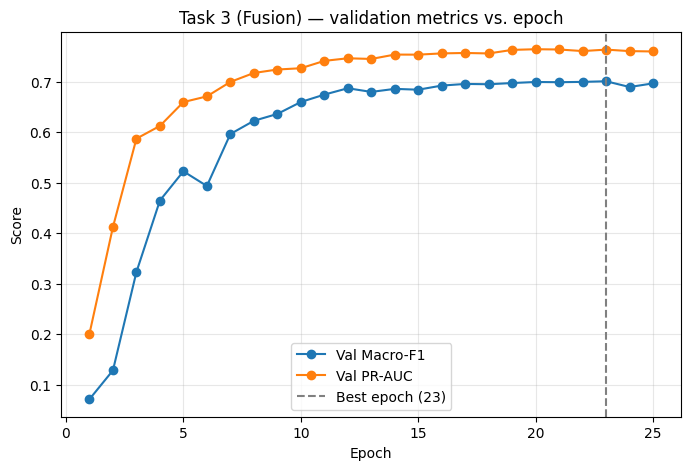

In [55]:
import matplotlib.pyplot as plt

epochs_list = [h["epoch"] for h in fusion_history]
plt.figure(figsize=(8, 5))
plt.plot(epochs_list, [h["val_macro_f1"] for h in fusion_history], marker="o", label="Val Macro-F1")
plt.plot(epochs_list, [h["val_pr_auc"] for h in fusion_history], marker="o", label="Val PR-AUC")
plt.axvline(x=fusion_best_epoch, color="gray", linestyle="--", label=f"Best epoch ({fusion_best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("Score"); plt.title("Task 3 (Fusion) — validation metrics vs. epoch")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("results/plots/task3_metrics_vs_epoch.png", dpi=150, bbox_inches="tight")
plt.show()

# **Early-concat ablation**

In [56]:
class EarlyConcatFusionModel(nn.Module):
    """
    Same two encoders as FusionModel, but combines them by simple
    concatenation instead of cross-attention this isolates whether
    attention itself is doing useful work, or whether just having both
    signals present is enough.
    """
    def __init__(self, gnn_encoder, bert_model, num_tags=50, fused_dim=128):
        super().__init__()
        self.gnn = gnn_encoder
        self.bert = bert_model
        self.graph_proj = nn.Linear(gnn_encoder.out_dim, fused_dim)
        self.text_proj = nn.Linear(bert_model.config.hidden_size, fused_dim)
        self.tag_head = nn.Linear(fused_dim * 2, num_tags)
        self.emotion_head = nn.Linear(fused_dim * 2, 2)

    def forward(self, graph_x, graph_edge_index, graph_batch, input_ids, attention_mask):
        graph_vector = self.gnn(graph_x, graph_edge_index, graph_batch)
        cls_vector = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]

        g = self.graph_proj(graph_vector)
        t = self.text_proj(cls_vector)
        combined = torch.cat([g, t], dim=-1)  # plain concatenation, no attention

        return self.tag_head(combined), self.emotion_head(combined)

In [57]:
def train_task3_early_concat(mtat_train_loader, deam_train_loader, mtat_val_loader, mtat_test_loader,
                               tokenizer, device, num_epochs=25, patience=5, alpha=0.3):
    
    gnn_encoder = GNNEncoder(in_dim=128, hidden_dim=128, num_layers=3, dropout=0.2)
    bert_model = AutoModel.from_pretrained("bert-base-uncased")
    freeze_bottom_layers(bert_model, num_layers_to_freeze=8)
    model = EarlyConcatFusionModel(gnn_encoder, bert_model, num_tags=50).to(device)

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
    best_val_f1, best_state, best_epoch, epochs_without_improvement = 0.0, None, None, 0
    history = []

    def run_eval(loader):
        model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                tag_logits, _ = model(batch.x, batch.edge_index, batch.batch, batch.input_ids, batch.attention_mask)
                all_logits.append(tag_logits.cpu()); all_labels.append(batch.y.cpu())
        probs = torch.sigmoid(torch.cat(all_logits)).numpy()
        preds = (probs > 0.5).astype(int)
        labels_np = torch.cat(all_labels).numpy()
        return {
            "macro_f1": f1_score(labels_np, preds, average="macro", zero_division=0),
            "micro_f1": f1_score(labels_np, preds, average="micro", zero_division=0),
            "pr_auc": average_precision_score(labels_np, probs, average="macro"),
        }

    for epoch in range(num_epochs):
        model.train()
        total_loss, num_batches = 0, 0
        for batch in mtat_train_loader:
            batch = batch.to(device)
            tag_logits, emotion_pred = model(batch.x, batch.edge_index, batch.batch, batch.input_ids, batch.attention_mask)
            loss, tag_l, _ = fusion_loss(tag_logits, emotion_pred, batch, alpha)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += tag_l; num_batches += 1

        for batch in deam_train_loader:
            batch = batch.to(device)
            tag_logits, emotion_pred = model(batch.x, batch.edge_index, batch.batch, batch.input_ids, batch.attention_mask)
            loss, _, _ = fusion_loss(tag_logits, emotion_pred, batch, alpha)
            optimizer.zero_grad(); loss.backward(); optimizer.step()

        val_metrics = run_eval(mtat_val_loader)
        history.append({"epoch": epoch + 1, "val_macro_f1": val_metrics["macro_f1"], "val_pr_auc": val_metrics["pr_auc"]})
        print(f"[Early-concat] Epoch {epoch+1} | loss: {total_loss/num_batches:.4f} | val macro-F1: {val_metrics['macro_f1']:.4f}")

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1, best_epoch = val_metrics["macro_f1"], epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"No improvement for {patience} epochs — stopping at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    test_metrics = run_eval(mtat_test_loader)
    print(f"[Early-concat] Final TEST metrics (best epoch {best_epoch}):", test_metrics)
    return model, test_metrics, history, best_epoch

In [58]:
concat_model, concat_test_metrics, concat_history, concat_best_epoch = train_task3_early_concat(
    train_fusion_loader, deam_fusion_loader, val_fusion_loader, test_fusion_loader,
    tokenizer, device, num_epochs=25, patience=5
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Early-concat] Epoch 1 | loss: 0.2200 | val macro-F1: 0.0948
[Early-concat] Epoch 2 | loss: 0.1375 | val macro-F1: 0.4584
[Early-concat] Epoch 3 | loss: 0.1203 | val macro-F1: 0.5622
[Early-concat] Epoch 4 | loss: 0.1108 | val macro-F1: 0.6479
[Early-concat] Epoch 5 | loss: 0.1042 | val macro-F1: 0.6140
[Early-concat] Epoch 6 | loss: 0.0998 | val macro-F1: 0.6506
[Early-concat] Epoch 7 | loss: 0.0962 | val macro-F1: 0.6918
[Early-concat] Epoch 8 | loss: 0.0936 | val macro-F1: 0.7001
[Early-concat] Epoch 9 | loss: 0.0916 | val macro-F1: 0.7076
[Early-concat] Epoch 10 | loss: 0.0899 | val macro-F1: 0.7030
[Early-concat] Epoch 11 | loss: 0.0883 | val macro-F1: 0.7171
[Early-concat] Epoch 12 | loss: 0.0870 | val macro-F1: 0.7078
[Early-concat] Epoch 13 | loss: 0.0861 | val macro-F1: 0.7125
[Early-concat] Epoch 14 | loss: 0.0849 | val macro-F1: 0.7119
[Early-concat] Epoch 15 | loss: 0.0839 | val macro-F1: 0.7152
[Early-concat] Epoch 16 | loss: 0.0831 | val macro-F1: 0.7196
[Early-concat] Ep

In [60]:
with open("results/metrics_task3_early_concat.json", "w") as f:
    json.dump(concat_test_metrics, f, indent=2, default=float)
print("Saved.")

Saved.


# **t-SNE of the fused representation**

In [59]:
from sklearn.manifold import TSNE

genre_tags = ["classical", "techno", "rock", "pop", "country", "metal", "opera", "new age", "dance"]
mood_tags = ["slow", "fast", "ambient", "loud", "quiet", "soft", "weird"]

def get_first_match(row, tag_list):
    for tag in tag_list:
        if row[tag] == 1:
            return tag
    return "other"

test_df["genre_label"] = test_df.apply(lambda row: get_first_match(row, genre_tags), axis=1)
test_df["mood_label"] = test_df.apply(lambda row: get_first_match(row, mood_tags), axis=1)

@torch.no_grad()
def extract_fused_vectors(model, loader, device):
    model.eval()
    all_z = []
    for batch in loader:
        batch = batch.to(device)
        graph_vector = model.gnn(batch.x, batch.edge_index, batch.batch)
        text_tokens = model.bert(input_ids=batch.input_ids, attention_mask=batch.attention_mask).last_hidden_state
        g = model.graph_proj(graph_vector).unsqueeze(1)
        t = model.text_proj(text_tokens)
        attended_text, _ = model.attention(query=g, key=t, value=t)
        combined = torch.cat([g.squeeze(1), attended_text.squeeze(1)], dim=-1)
        all_z.append(combined.cpu())
    return torch.cat(all_z).numpy()

fused_vectors = extract_fused_vectors(fusion_model, test_fusion_loader, device)
print("Fused vectors shape:", fused_vectors.shape)

Fused vectors shape: (4332, 256)


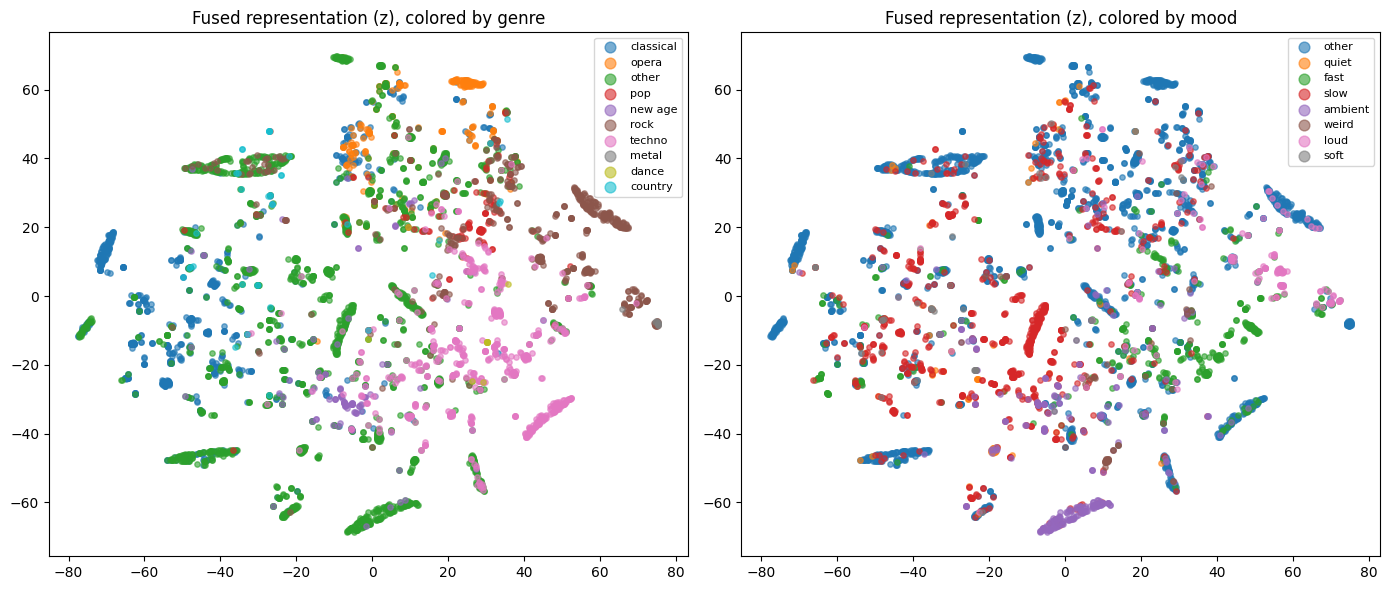

In [61]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
z_2d = tsne.fit_transform(fused_vectors)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label in test_df["genre_label"].unique():
    mask = (test_df["genre_label"] == label).values
    axes[0].scatter(z_2d[mask, 0], z_2d[mask, 1], label=label, alpha=0.6, s=15)
axes[0].set_title("Fused representation (z), colored by genre")
axes[0].legend(fontsize=8, markerscale=2)

for label in test_df["mood_label"].unique():
    mask = (test_df["mood_label"] == label).values
    axes[1].scatter(z_2d[mask, 0], z_2d[mask, 1], label=label, alpha=0.6, s=15)
axes[1].set_title("Fused representation (z), colored by mood")
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig("results/plots/task3_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

# **Three case studies (graph structure + caption alignment)**

2429 test clips have 3+ true tags to choose from.
--- Case study 1 (test index 640) ---
Caption shown to model: synth new age
True tags: ['slow', 'ambient', 'synth', 'new age']
Top attended words: [('age', np.float32(0.029274084)), ('new', np.float32(0.022690099)), ('synth', np.float32(0.022511624))]

--- Case study 2 (test index 3290) ---
Caption shown to model: beat loud
True tags: ['techno', 'electronic', 'beat', 'loud']
Top attended words: [('loud', np.float32(0.026590098)), ('beat', np.float32(0.024089253))]

--- Case study 3 (test index 2262) ---
Caption shown to model: strings flute
True tags: ['classical', 'strings', 'violin', 'flute']
Top attended words: [('strings', np.float32(0.021960234)), ('flute', np.float32(0.021631677))]



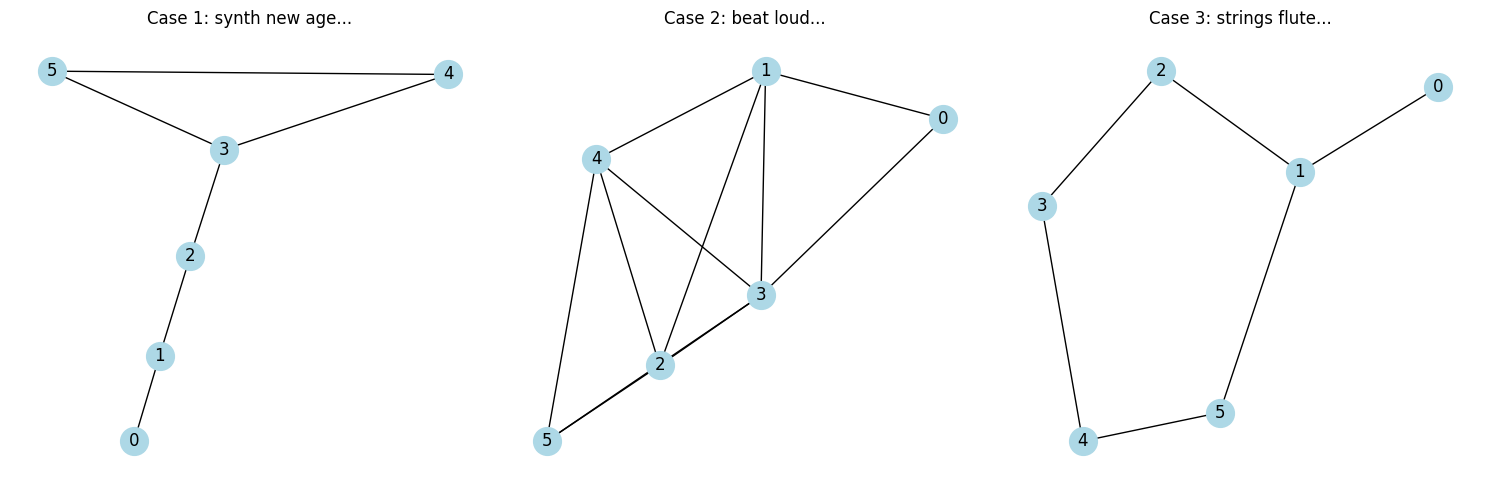

In [65]:
import networkx as nx


tag_counts_per_clip = test_df[top_50_tags].sum(axis=1)
rich_candidates = tag_counts_per_clip[tag_counts_per_clip >= 3].index.tolist()
print(f"{len(rich_candidates)} test clips have 3+ true tags to choose from.")

np.random.seed(3)
case_study_indices = np.random.choice(rich_candidates, size=3, replace=False).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, idx in enumerate(case_study_indices):
    row = test_df.iloc[idx]
    graph = torch.load(f"data/processed/{row['clip_id']}.pt", weights_only=False)

    caption = test_fusion_dataset.captions[idx]
    tokens = tokenizer(caption, padding="max_length", truncation=True, max_length=32, return_tensors="pt").to(device)

    fusion_model.eval()
    with torch.no_grad():
        graph_vector = fusion_model.gnn(
            graph.x.to(device), graph.edge_index.to(device),
            torch.zeros(graph.x.size(0), dtype=torch.long, device=device)
        )
        text_tokens = fusion_model.bert(**tokens).last_hidden_state
        g = fusion_model.graph_proj(graph_vector).unsqueeze(1)
        t = fusion_model.text_proj(text_tokens)
        _, attn_weights = fusion_model.attention(query=g, key=t, value=t)

    word_tokens = tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])
    weights = attn_weights[0, 0].cpu().numpy()


    content_pairs = [(w, wt) for w, wt in zip(word_tokens, weights) if w not in ("[PAD]", "[CLS]", "[SEP]")]
    top_words = sorted(content_pairs, key=lambda x: -x[1])[:5]

    print(f"--- Case study {i+1} (test index {idx}) ---")
    print("Caption shown to model:", caption)
    print("True tags:", [tag for tag in top_50_tags if row[tag] == 1])
    print("Top attended words:", top_words)
    print()

    G = nx.Graph()
    G.add_nodes_from(range(graph.x.size(0)))
    G.add_edges_from(graph.edge_index.t().tolist())
    nx.draw(G, with_labels=True, node_color="lightblue", node_size=400, ax=axes[i])
    axes[i].set_title(f"Case {i+1}: {caption[:30]}...")

plt.tight_layout()
plt.savefig("results/plots/task3_case_studies.png", dpi=150, bbox_inches="tight")
plt.show()

In [66]:
import json

with open("results/task3_case_studies.txt", "w") as f:
    for i, idx in enumerate(case_study_indices):
        row = test_df.iloc[idx]
        f.write(f"Case study {i+1} (test index {idx})\n")
        f.write(f"Caption: {test_fusion_dataset.captions[idx]}\n")
        f.write(f"True tags: {[tag for tag in top_50_tags if row[tag] == 1]}\n\n")
print("Saved.")

Saved.
